In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf 
import seaborn as sns

In [3]:
inflation = pd.read_csv('Data/inflationimf.csv')

intrates = pd.read_csv('Data/intratesimf.csv')

cbi = pd.read_excel('Data/CBIData_Romelli_2025.xlsx', sheet_name = 1, usecols = ['country', 'year', 'cbie_index', 'iso_a3'])

In [3]:
inflation = inflation.rename(columns={
    'COUNTRY.ID': 'iso3',
    'TIME_PERIOD': 'year',
    'OBS_VALUE': 'inflation'
})

intrates = intrates.rename(columns={
    'COUNTRY.ID': 'iso3',
    'TIME_PERIOD': 'year',
    'OBS_VALUE': 'interest_rate'
})

cbi = cbi.rename(columns={'iso_a3': 'iso3'})

In [4]:
set_imf = set(inflation['iso3']) | set(intrates['iso3'])
set_cbi = set(cbi['iso3'])

# print("IMF − CBI (countries IMF has that CBI does not):")
# print(set_imf - set_cbi)

# print("\nCBI − IMF (countries CBI has that IMF does not):")
# print(set_cbi - set_imf)

valid = set_imf & set_cbi

inflation = inflation[inflation['iso3'].isin(valid)]
intrates  = intrates[intrates['iso3'].isin(valid)]
cbi       = cbi[cbi['iso3'].isin(valid)]

In [5]:
cbi = cbi.sort_values(['iso3', 'year'])

cbi['cbie_diff'] = cbi.groupby('iso3')['cbie_index'].diff()
change = cbi[cbi['cbie_diff'] > 0]

reform_years = (change.groupby('iso3')['year'].min().rename('reform_year')) # First time a country experiences a structural change

CUTOFF = 1980
modern_reforms = reform_years[reform_years >= CUTOFF]

# df_imf = inflation.merge(intrates, on=['iso3', 'year'], how='inner')

df = inflation.merge(cbi, on=['iso3', 'year'], how='inner')

df = df.merge(modern_reforms.rename('reform_year'), on = 'iso3', how = 'inner')

df.head()

,iso3,year,inflation,country,cbie_index,cbie_diff,reform_year
0,GBR,1956,4.980457,United Kingdom,0.1795,0.0,1993
1,GBR,1957,3.691304,United Kingdom,0.1795,0.0,1993
2,GBR,1958,2.992827,United Kingdom,0.1795,0.0,1993
3,GBR,1959,0.581176,United Kingdom,0.1795,0.0,1993
4,GBR,1960,1.003576,United Kingdom,0.1795,0.0,1993


In [6]:
# df[df['reform_year'].notna()]
df['iso3'].nunique(), df[df['reform_year'].notna()]['iso3'].nunique()

(115, 115)

<h1>Event Study Code</h1>

In [7]:
df = df.sort_values(['iso3', 'year'])
df.head()

,iso3,year,inflation,country,cbie_index,cbie_diff,reform_year
1795,AGO,2003,98.224144,Angola,0.637,0.0,2010
1796,AGO,2004,43.542107,Angola,0.637,0.0,2010
1797,AGO,2005,22.953514,Angola,0.637,0.0,2010
1798,AGO,2006,13.305210,Angola,0.637,0.0,2010
1799,AGO,2007,12.251497,Angola,0.637,0.0,2010


In [8]:
df = df[df['year'] >= CUTOFF].copy()

df['rel_year'] = df['year'] - df['reform_year']

WINDOW = 10

df_evt = df[df['reform_year'].notna()].copy()
df_evt = df_evt[df_evt['rel_year'].between(-WINDOW, WINDOW)]

df_evt.head()

# counts = df_evt['rel_year'].value_counts().sort_index()
# print(counts)

,iso3,year,inflation,country,cbie_index,cbie_diff,reform_year,rel_year
1795,AGO,2003,98.224144,Angola,0.637,0.0,2010,-7
1796,AGO,2004,43.542107,Angola,0.637,0.0,2010,-6
1797,AGO,2005,22.953514,Angola,0.637,0.0,2010,-5
1798,AGO,2006,13.305210,Angola,0.637,0.0,2010,-4
1799,AGO,2007,12.251497,Angola,0.637,0.0,2010,-3


In [9]:
## Creating lagged interest rates

# df_evt['interest_rate_lag1'] = df_evt.groupby('iso3')['interest_rate'].shift(1)
# df_reg = df_evt.dropna(subset=['interest_rate_lag1']).copy()

df_reg = df_evt # temporary
df_reg['rel_year'] = df_reg['rel_year'].astype(int)
df_reg2 = df_reg.copy()
df_reg.head()


,iso3,year,inflation,country,cbie_index,cbie_diff,reform_year,rel_year
1795,AGO,2003,98.224144,Angola,0.637,0.0,2010,-7
1796,AGO,2004,43.542107,Angola,0.637,0.0,2010,-6
1797,AGO,2005,22.953514,Angola,0.637,0.0,2010,-5
1798,AGO,2006,13.305210,Angola,0.637,0.0,2010,-4
1799,AGO,2007,12.251497,Angola,0.637,0.0,2010,-3


In [10]:
df_reg = df_reg.rename(columns={'rel_year': 'time_to_treat'})

df_reg = pd.get_dummies(df_reg, columns = ['time_to_treat'], prefix='Di', dtype = int)

In [11]:
df_reg.rename(columns=lambda x: x.replace('-', 'm'), inplace=True)
df_reg.drop(columns=['Di_m1'], inplace=True)

df_reg.head()

,iso3,year,inflation,country,cbie_index,cbie_diff,reform_year,Di_m10,Di_m9,Di_m8,...,Di_1,Di_2,Di_3,Di_4,Di_5,Di_6,Di_7,Di_8,Di_9,Di_10
1795,AGO,2003,98.224144,Angola,0.637,0.0,2010,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1796,AGO,2004,43.542107,Angola,0.637,0.0,2010,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1797,AGO,2005,22.953514,Angola,0.637,0.0,2010,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1798,AGO,2006,13.305210,Angola,0.637,0.0,2010,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1799,AGO,2007,12.251497,Angola,0.637,0.0,2010,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
df_reg['decade'] = (df_reg['year'] // 10) * 10

endog = 'inflation'

indicators = df_reg.columns[df_reg.columns.str.startswith('Di_')]
# controls = ['interest_rate_lag1']

formula = "{} ~ {} + C(iso3) + C(decade)".format(
    endog,
    '+'.join(indicators),
    # '+'.join(controls)
)

We use decade fixed effects here because year fixed effects unfortunately cause collinearity.

In [13]:
event_res = smf.ols(formula=formula, data=df_reg).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['iso3']}
)

print(event_res.summary())

                            OLS Regression Results                            
Dep. Variable:              inflation   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     44.48
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           1.55e-39
Time:                        20:36:21   Log-Likelihood:                -6610.3
No. Observations:                1168   AIC:                         1.345e+04
Df Residuals:                    1054   BIC:                         1.403e+04
Df Model:                         113                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.8470     21.75

C:\Users\dylan\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 113, but rank is 24
  warnings.warn('covariance of constraints does not have full '


In [14]:
res = pd.concat([event_res.conf_int(alpha=0.05), event_res.params], axis = 1)
res.columns = ['lower_ci','upper_ci','est']
res

,lower_ci,upper_ci,est
Intercept,-39.789349,45.483262,2.846956
C(iso3)[T.ARE],-55.685891,-21.145581,-38.415736
C(iso3)[T.AUS],-27.559359,-6.314862,-16.937110
C(iso3)[T.AUT],-28.593408,-7.348911,-17.971159
C(iso3)[T.AZE],-14.572707,16.845949,1.136621
...,...,...,...
Di_6,-27.699607,-0.352274,-14.025940
Di_7,-30.324689,-0.861181,-15.592935
Di_8,-33.016931,-1.006944,-17.011938
Di_9,-34.931825,-1.298710,-18.115268


In [15]:
# We only want the indicators
res = res.filter(like='Di', axis=0)
# Turn the coefficient names back to numbers
res.index = (
    res.index
        .str.replace('Di_', '')
        .str.replace('m', '-')
        .astype('int')
        .rename('time_to_treat')
)
# sort the index
res_sorted = res.sort_index()
res_sorted

,lower_ci,upper_ci,est
time_to_treat,,,
-10,-3.934593,61.496447,28.780927
-9,-9.185261,48.616226,19.715482
-8,-8.116533,28.258392,10.070929
-7,-25.381946,89.890803,32.254429
-6,-38.175307,126.238616,44.031655
-5,-18.567586,83.843714,32.638064
-4,-9.601356,9.751346,0.074995
-3,-10.105510,5.202957,-2.451276
-2,-11.723455,35.918619,12.097582


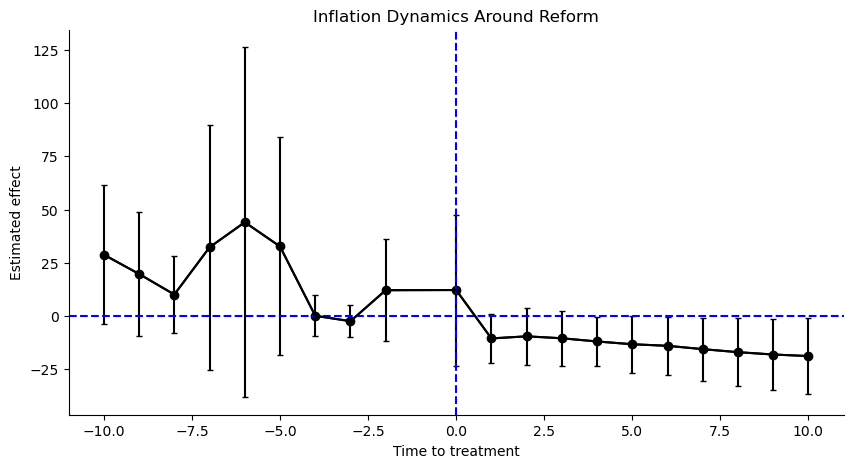

In [37]:
fig, ax = plt.subplots(figsize=(10,5)) 

ax.plot(res_sorted.index, res_sorted['est'], marker='o', color='black',)
ax.errorbar(res.index, res['est'], yerr=res['est']-res['lower_ci'], color='black',capsize=2)
# Alternative: Fill between
#ax.fill_between(res_sorted.index, res_sorted['lower_ci'], res_sorted['upper_ci'], color='blue', alpha=0.1) 

# Add a horizontal line at 0
ax.axhline(0, linestyle='dashed', color='blue')
# And a vertical line at the treatment time
ax.axvline(0, linestyle='dashed', color='blue')

sns.despine(ax=ax)
ax.set_title('Inflation Dynamics Around Reform')
ax.set_xlabel('Time to treatment')
ax.set_ylabel('Estimated effect')

plt.show()

<h2>Robustness Checks</h2>

<h4>Parallel Trends F-Test</h4>

In [19]:
indicators = [col for col in df_reg.columns if col.startswith("Di_")]

# keep only pre-treatment ones (negative rel_year)
pre_treat_vars = [col for col in indicators if "_m" in col]

# making sure they are in the model params (just in case)
pre_treat_vars = [v for v in pre_treat_vars if v in event_res.params.index]

# hypothesis string: "Di_m10 = 0, Di_m9 = 0, ..."
hypothesis = ', '.join(f"{v} = 0" for v in pre_treat_vars)

f_test = event_res.f_test(hypothesis)
print("Pre-trends F-test p-value:", float(f_test.pvalue))

Pre-trends F-test p-value: 0.5650573802013514


We conduct a joint F-test of all pre-treatment event coefficients to evaluate the parallel trends assumption. The test yields a p-value of 0.565, indicating that we cannot reject the hypothesis that pre-treatment coefficients are jointly zero. This provides strong evidence that treated and control countries followed parallel inflation dynamics prior to CBI reforms, satisfying a key identifying assumption of the event-study design.

<h4>Endogeneity Screen</h4>

Allowing for inflation crises in one year before or after reform identifies four potentially crisis-driven reforms, which we exclude in a robustness check. High inflation events are acting as a proxy for an unobserved crisis state. We also drop observations with annual inflation higher than 50%.

In [20]:
df_no_crisis = df_reg2
df_no_crisis = df_no_crisis.rename({"rel_year":"time_to_treat"}, axis = 1)

df_no_crisis = df_no_crisis[df_no_crisis['inflation'] < 50]

dist = df_no_crisis["year"] - df_no_crisis["reform_year"]

crisis_reform = (df_no_crisis["inflation"] > 20) & (dist.abs() <= 1)

# countries with "inflation crisis-driven reforms" (to address endogeneity concerns)
crisis_countries = df_no_crisis.loc[crisis_reform, "iso3"].unique()

# remove their reform timing
df_no_crisis.loc[df_no_crisis["iso3"].isin(crisis_countries), "reform_year"] = np.nan

df_no_crisis["time_to_treat"] = (df_no_crisis["year"] - df_no_crisis["reform_year"]).round().astype("Int64")

df_no_crisis.head()
# df_no_crisis['time_to_treat'].value_counts()

,iso3,year,inflation,country,cbie_index,cbie_diff,reform_year,time_to_treat
1796,AGO,2004,43.542107,Angola,0.637,0.0,2010.0,-6
1797,AGO,2005,22.953514,Angola,0.637,0.0,2010.0,-5
1798,AGO,2006,13.305210,Angola,0.637,0.0,2010.0,-4
1799,AGO,2007,12.251497,Angola,0.637,0.0,2010.0,-3
1800,AGO,2008,12.475829,Angola,0.637,0.0,2010.0,-2


In [21]:
print(f"Number of cohorts dropped: {len(crisis_countries)}, which are {crisis_countries}")

Number of cohorts dropped: 13, which are ['COL' 'CRI' 'ECU' 'ETH' 'GHA' 'GIN' 'IRN' 'ISL' 'LTU' 'MDA' 'MWI' 'RUS'
 'TUR']


In [22]:
WINDOW = 10

df_no_crisis = df_no_crisis[df_no_crisis["time_to_treat"].between(-WINDOW, WINDOW) | df_no_crisis["time_to_treat"].isna()] 

df_no_crisis = pd.get_dummies(
    df_no_crisis,
    columns=["time_to_treat"],
    prefix="Di",
    dtype=int
)

df_no_crisis.rename(columns=lambda x: x.replace("-", "m"), inplace=True)

df_no_crisis.drop(columns=["Di_m1"], inplace=True)


In [23]:
df_no_crisis['decade'] = (df_no_crisis['year'] // 10) * 10

endog = 'inflation'

indicators = df_no_crisis.columns[df_no_crisis.columns.str.startswith('Di_')]


formula = "{} ~ {} + C(iso3) + C(decade)".format(
    endog,
    '+'.join(indicators),
    # '+'.join(controls)
)

event_res_endog = smf.ols(formula=formula, data=df_no_crisis).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_no_crisis['iso3']}
)

print(event_res_endog.summary())

                            OLS Regression Results                            
Dep. Variable:              inflation   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.569
Method:                 Least Squares   F-statistic:                     171.5
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           3.28e-64
Time:                        20:38:29   Log-Likelihood:                -3483.7
No. Observations:                1128   AIC:                             7195.
Df Residuals:                    1014   BIC:                             7769.
Df Model:                         113                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            24.2199      2.95

C:\Users\dylan\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 113, but rank is 24
  warnings.warn('covariance of constraints does not have full '


In [24]:
# df_no_crisis.loc[
#     df_no_crisis["iso3"].isin(crisis_countries),
#     [c for c in df_no_crisis.columns if c.startswith("Di_")]
# ].sum()

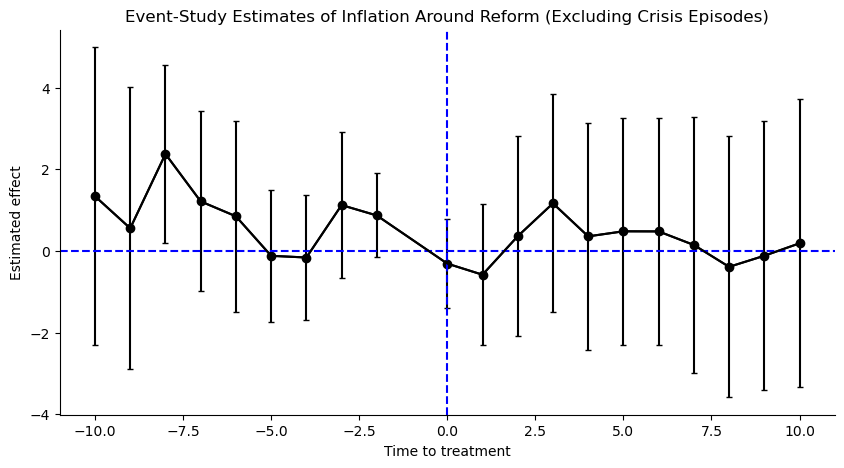

In [25]:
res2 = pd.concat([event_res_endog.conf_int(alpha=0.05), event_res_endog.params], axis = 1)
res2.columns = ['lower_ci','upper_ci','est']

# We only want the indicators
res2 = res2.filter(like='Di', axis=0)
# Turn the coefficient names back to numbers
res2.index = (
    res2.index
        .str.replace('Di_', '')
        .str.replace('m', '-')
        .astype('int')
        .rename('time_to_treat')
)
# sort the index
res2_sorted = res2.sort_index()

fig, ax = plt.subplots(figsize=(10,5)) 

ax.plot(res2_sorted.index, res2_sorted['est'], marker='o', color='black',)
ax.errorbar(res2.index, res2['est'], yerr=res2['est']-res2['lower_ci'], color='black',capsize=2)
# Alternative: Fill between
#ax.fill_between(res_sorted.index, res_sorted['lower_ci'], res_sorted['upper_ci'], color='blue', alpha=0.1) 

# Add a horizontal line at 0
ax.axhline(0, linestyle='dashed', color='blue')
# And a vertical line at the treatment time
ax.axvline(0, linestyle='dashed', color='blue')

sns.despine(ax=ax)
ax.set_title('Event-Study Estimates of Inflation Around Reform (Excluding Crisis Episodes)')
ax.set_xlabel('Time to treatment')
ax.set_ylabel('Estimated effect')

plt.show()


In non-crisis settings, inflation dynamics around reform are flat and statistically indistinguishable from zero, suggesting that reforms are not systematically associated with inflationary or disinflationary pressures.

In [27]:
indicators = [col for col in df_no_crisis.columns if col.startswith("Di_")]

# keep only pre-treatment ones (negative rel_year)
pre_treat_vars = [col for col in indicators if "_m" in col]

# making sure they are in the model params (just in case)
pre_treat_vars = [v for v in pre_treat_vars if v in event_res_endog.params.index]

# hypothesis string: "Di_m10 = 0, Di_m9 = 0, ..."
hypothesis = ', '.join(f"{v} = 0" for v in pre_treat_vars)

f_test = event_res_endog.f_test(hypothesis)
print("Pre-trends F-test p-value:", float(f_test.pvalue))

Pre-trends F-test p-value: 0.13736159452905924


In [28]:
df_lag = df_no_crisis.sort_values(["iso3", "year"]).copy()
df_lag["infl_l1"] = df_lag.groupby("iso3")["inflation"].shift(1)
df_lag = df_lag.dropna(subset = ['infl_l1'].copy())

In [29]:
df_lag['decade'] = (df_lag['year'] // 10) * 10

endog = 'inflation'

indicators = df_lag.columns[df_lag.columns.str.startswith('Di_')]


formula = "{} ~ {} + infl_l1 + C(iso3) + C(decade)".format(
    endog,
    '+'.join(indicators),
    # '+'.join(controls)
)

event_res_lag = smf.ols(formula=formula, data=df_lag).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_lag['iso3']}
)

print(event_res_lag.summary())

                            OLS Regression Results                            
Dep. Variable:              inflation   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     10.19
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           1.42e-16
Time:                        20:40:21   Log-Likelihood:                -2942.7
No. Observations:                1038   AIC:                             6113.
Df Residuals:                     924   BIC:                             6677.
Df Model:                         113                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            11.0997      2.05

C:\Users\dylan\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 114, but rank is 24
  warnings.warn('covariance of constraints does not have full '


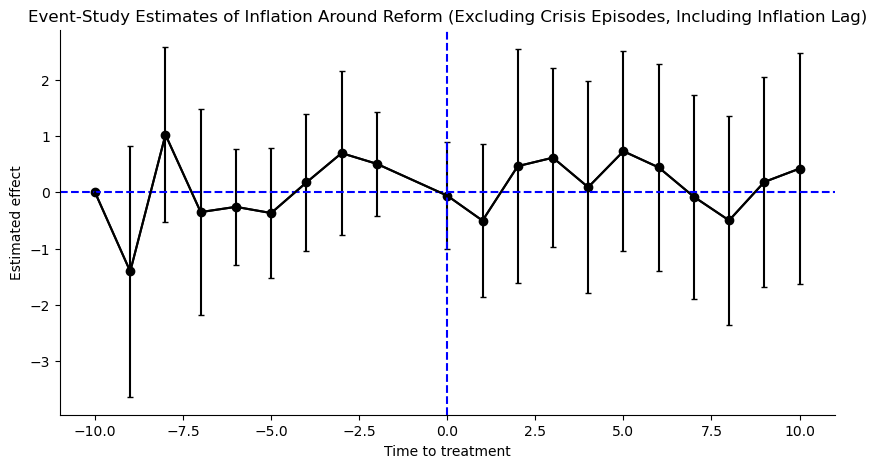

In [34]:
res3 = pd.concat([event_res_lag.conf_int(alpha=0.05), event_res_lag.params], axis = 1)
res3.columns = ['lower_ci','upper_ci','est']

# We only want the indicators
res3 = res3.filter(like='Di', axis=0)
# Turn the coefficient names back to numbers
res3.index = (
    res3.index
        .str.replace('Di_', '')
        .str.replace('m', '-')
        .astype('int')
        .rename('time_to_treat')
)
# sort the index
res3_sorted = res3.sort_index()

fig, ax = plt.subplots(figsize=(10,5)) 

ax.plot(res3_sorted.index, res3_sorted['est'], marker='o', color='black',)
ax.errorbar(res3.index, res3['est'], yerr=res3['est']-res3['lower_ci'], color='black',capsize=2)
# Alternative: Fill between
# ax.fill_between(res_sorted.index, res_sorted['lower_ci'], res_sorted['upper_ci'], color='blue', alpha=0.1) 

# Add a horizontal line at 0
ax.axhline(0, linestyle='dashed', color='blue')
# And a vertical line at the treatment time
ax.axvline(0, linestyle='dashed', color='blue')

sns.despine(ax=ax)
ax.set_title('Event-Study Estimates of Inflation Around Reform (Excluding Crisis Episodes, Including Inflation Lag)')
ax.set_xlabel('Time to treatment')
ax.set_ylabel('Estimated effect')

plt.show()

In [31]:
indicators = [col for col in df_lag.columns if col.startswith("Di_")]

# keep only pre-treatment ones (negative rel_year)
pre_treat_vars = [col for col in indicators if "_m" in col]

# making sure they are in the model params (just in case)
pre_treat_vars = [v for v in pre_treat_vars if v in event_res_lag.params.index]

# hypothesis string: "Di_m10 = 0, Di_m9 = 0, ..."
hypothesis = ', '.join(f"{v} = 0" for v in pre_treat_vars)

f_test = event_res_lag.f_test(hypothesis)
print("Pre-trends F-test p-value:", float(f_test.pvalue))

Pre-trends F-test p-value: 0.08199116015993171


C:\Users\dylan\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 8
  warnings.warn('covariance of constraints does not have full '


Once crisis episodes are excluded, inflation exhibits no systematic response to reform. Both pre- and post-treatment coefficients remain close to zero, suggesting that reforms implemented outside of macroeconomic crises do not materially affect inflation outcomes.